In [3]:
#pkgs <- c("glmmTMB", "sf", "dplyr", "DHARMa", "performance", "car", "effects")
#to_install <- setdiff(pkgs, installed.packages()[,1])
#if (length(to_install)) install.packages(to_install, dependencies = TRUE)

In [4]:
library(mgcv)
library(dplyr)
library(readr)
library(ggplot2)


In [5]:

getwd()

[1] "D:/Maple/Articule_Maple"

In [6]:
df <- read.csv("data/Full_dataset_clustering.csv")

In [8]:
head(df)

,X,essence,latitude,forest,longitude,elev,ph,clay,sand,bio1,⋯,bio18,bio20,bio23,bio24,bio27,bio30,bio31,bio34,wetland_mean_500km,cluster_k
,<int>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,575965,EO,47.76121,100,-73.02245,344,4.5000,85,85,1.7658631,⋯,301.000,19.05128,78.62516,588.1000,35.53505,-6.559094,9.199162,733.5757,0,1
2,1031063,EO,46.43262,100,-75.44540,239,5.1067,13,51,3.3387084,⋯,294.750,17.74784,75.75904,625.5750,33.81523,-1.487061,8.546481,798.4433,0,3
3,909255,EO,46.02892,100,-74.74501,285,5.5000,2,93,2.9426208,⋯,304.150,16.63733,82.13432,653.2500,33.67498,-4.342159,6.658854,784.0029,0,3
4,69805,EO,46.83903,100,-70.51925,363,3.5167,24,45,3.2645202,⋯,343.700,15.86132,91.07240,721.9499,32.35521,-5.601314,10.016439,715.8235,0,0
5,1519641,EO,48.08064,91,-79.39838,331,5.7000,90,0,0.8687378,⋯,261.750,20.98792,76.24040,541.9000,36.52759,-11.209414,9.943170,717.1036,0,1
6,481637,EO,47.24875,100,-72.58881,351,4.5000,85,85,1.9776856,⋯,307.025,18.16716,81.37191,612.6000,34.90568,-3.097126,8.113780,741.6219,0,1


In [9]:
colnames(df)

[1] "X"                  "essence"            "latitude"          
 [4] "forest"             "longitude"          "elev"              
 [7] "ph"                 "clay"               "sand"              
[10] "bio1"               "bio2"               "bio3"              
[13] "bio8"               "bio9"               "bio10"             
[16] "bio11"              "bio12"              "bio14"             
[19] "bio15"              "bio18"              "bio20"             
[22] "bio23"              "bio24"              "bio27"             
[25] "bio30"              "bio31"              "bio34"             
[28] "wetland_mean_500km" "cluster_k"

In [10]:
df <- df %>%
  filter(essence %in% c("ES", "EO")) %>%
  mutate(
    essence = factor(essence, levels = c("ES", "EO")),
    essence_bin = as.numeric(essence == "EO")  # 1 para EO, 0 para ES
  )


In [12]:
# Puedes cambiar 'bs = "tp"' a 'bs = "gp"' para mayor eficiencia con millones de datos
formula_gam <- essence_bin ~
  forest + elev + ph + clay + sand +
  bio1 + bio2 + bio3 + bio8 + bio9 + bio10 + bio11 + bio12 +
  bio14 + bio15 + bio18 + bio20 + bio23 + bio24 + bio27 +
  bio30 + bio31 + bio34 +
  s(longitude, latitude, bs = "tp", k = 100)  # Ajusta k si es necesario


In [14]:
gam_fit <- bam(
  formula = formula_gam,
  data = df,
  family = binomial(link = "logit"),
  method = "fREML",   # más rápido que REML
  discrete = TRUE,    # acelera usando aproximaciones de convolución
  nthreads = 6        # ajusta según tus cores disponibles
)

Warning message in bgam.fitd(G, mf, gp, scale, nobs.extra = 0, rho = rho, coef = coef, :
"fitted probabilities numerically 0 or 1 occurred"


In [15]:
summary(gam_fit)


Family: binomial 
Link function: logit 

Formula:
essence_bin ~ forest + elev + ph + clay + sand + bio1 + bio2 + 
    bio3 + bio8 + bio9 + bio10 + bio11 + bio12 + bio14 + bio15 + 
    bio18 + bio20 + bio23 + bio24 + bio27 + bio30 + bio31 + bio34 + 
    s(longitude, latitude, bs = "tp", k = 100)

Parametric coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  6.822e+00  1.605e+00   4.252 2.12e-05 ***
forest      -1.901e-02  2.024e-04 -93.940  < 2e-16 ***
elev        -2.699e-03  2.907e-05 -92.859  < 2e-16 ***
ph          -1.476e-02  3.937e-03  -3.749 0.000178 ***
clay        -1.769e-04  1.081e-04  -1.637 0.101596    
sand         1.091e-03  1.460e-04   7.474 7.80e-14 ***
bio1        -1.415e+00  9.276e-02 -15.256  < 2e-16 ***
bio2        -1.574e-01  1.246e-01  -1.264 0.206383    
bio3        -1.723e-01  7.088e-02  -2.430 0.015079 *  
bio8         4.246e-02  3.719e-03  11.419  < 2e-16 ***
bio9         2.136e-03  2.965e-03   0.721 0.471206    
bio10        4.55

In [17]:
df$predicted_prob <- predict(gam_fit, type = "response")

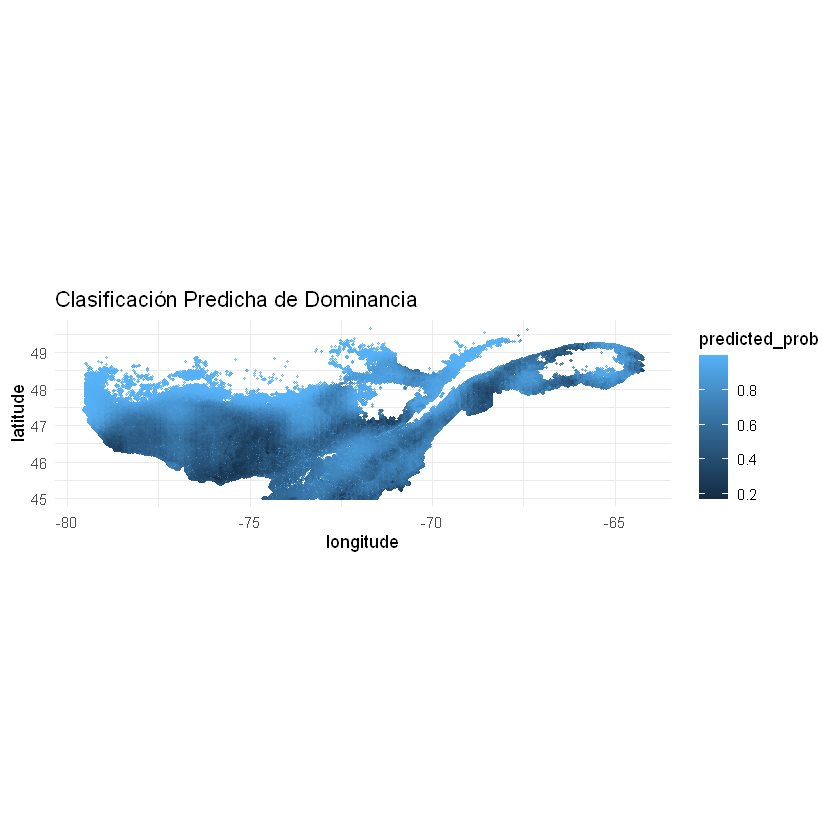

In [21]:
df$class <- ifelse(df$predicted_prob >= 0.5, "EO", "ES")
ggplot(df, aes(x = longitude, y = latitude, color = predicted_prob)) +
  geom_point(size = 0.5, alpha = 0.6) +
  #scale_color_manual(values = c("EO" = "blue", "ES" = "forestgreen")) +
  labs(title = "Clasificación Predicha de Dominancia") +
  coord_fixed() +
  theme_minimal()

In [22]:
df_export <- df %>%
  select(longitude, latitude, predicted_prob, class)

# Guardar como CSV
write.csv(df_export, "data/predicted_classes_maple.csv", row.names = FALSE)


In [23]:
head(df)

,X,essence,latitude,forest,longitude,elev,ph,clay,sand,bio1,⋯,bio24,bio27,bio30,bio31,bio34,wetland_mean_500km,cluster_k,essence_bin,predicted_prob,class
,<int>,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
1,575965,EO,47.76121,100,-73.02245,344,4.5000,85,85,1.7658631,⋯,588.1000,35.53505,-6.559094,9.199162,733.5757,0,1,1,0.7247280,EO
2,1031063,EO,46.43262,100,-75.44540,239,5.1067,13,51,3.3387084,⋯,625.5750,33.81523,-1.487061,8.546481,798.4433,0,3,1,0.4259500,ES
3,909255,EO,46.02892,100,-74.74501,285,5.5000,2,93,2.9426208,⋯,653.2500,33.67498,-4.342159,6.658854,784.0029,0,3,1,0.3800412,ES
4,69805,EO,46.83903,100,-70.51925,363,3.5167,24,45,3.2645202,⋯,721.9499,32.35521,-5.601314,10.016439,715.8235,0,0,1,0.5501460,EO
5,1519641,EO,48.08064,91,-79.39838,331,5.7000,90,0,0.8687378,⋯,541.9000,36.52759,-11.209414,9.943170,717.1036,0,1,1,0.9943090,EO
6,481637,EO,47.24875,100,-72.58881,351,4.5000,85,85,1.9776856,⋯,612.6000,34.90568,-3.097126,8.113780,741.6219,0,1,1,0.6353832,EO


In [24]:
vars <- c(
  'forest','elev','ph','clay','sand',
  'bio1','bio2','bio3','bio8','bio9','bio10','bio11','bio12',
  'bio14','bio15','bio18','bio20','bio23','bio24','bio27',
  'bio30','bio31','bio34'
)

In [25]:
make_partial_plot <- function(var_name,
                              scale = c("prob", "logit"),
                              base_size = 10,
                              n_points_rug = 200) {

  scale <- match.arg(scale)

  # Secuencia de la variable
  x_seq <- seq(
    quantile(df[[var_name]], 0.05, na.rm = TRUE),
    quantile(df[[var_name]], 0.95, na.rm = TRUE),
    length.out = 100
  )

  # Valores típicos para el resto
  base_vals <- df %>%
    summarise(
      forest = median(forest, na.rm = TRUE),
      elev = median(elev, na.rm = TRUE),
      ph = median(ph, na.rm = TRUE),
      clay = median(clay, na.rm = TRUE),
      sand = median(sand, na.rm = TRUE),
      bio1 = median(bio1, na.rm = TRUE),
      bio2 = median(bio2, na.rm = TRUE),
      bio3 = median(bio3, na.rm = TRUE),
      bio8 = median(bio8, na.rm = TRUE),
      bio9 = median(bio9, na.rm = TRUE),
      bio10 = median(bio10, na.rm = TRUE),
      bio11 = median(bio11, na.rm = TRUE),
      bio12 = median(bio12, na.rm = TRUE),
      bio14 = median(bio14, na.rm = TRUE),
      bio15 = median(bio15, na.rm = TRUE),
      bio18 = median(bio18, na.rm = TRUE),
      bio20 = median(bio20, na.rm = TRUE),
      bio23 = median(bio23, na.rm = TRUE),
      bio24 = median(bio24, na.rm = TRUE),
      bio27 = median(bio27, na.rm = TRUE),
      bio30 = median(bio30, na.rm = TRUE),
      bio31 = median(bio31, na.rm = TRUE),
      bio34 = median(bio34, na.rm = TRUE),
      longitude = median(longitude, na.rm = TRUE),
      latitude  = median(latitude, na.rm = TRUE)
    )

  newdat <- base_vals[rep(1, 100), ]
  newdat[[var_name]] <- x_seq

  # Predicción
  pr <- predict(gam_fit, newdata = newdat, type = "link", se.fit = TRUE)
  newdat$fit <- pr$fit
  newdat$se  <- pr$se.fit

  if (scale == "prob") {
    newdat <- newdat %>%
      mutate(
        y     = plogis(fit),
        lower = plogis(fit - 2 * se),
        upper = plogis(fit + 2 * se)
      )
    y_lab <- "P(EO)"
    y_limits <- c(0, 1)
  } else {
    newdat <- newdat %>%
      mutate(
        y     = fit,
        lower = fit - 2 * se,
        upper = fit + 2 * se
      )
    y_lab <- "logit(P(EO))"
    y_limits <- NA
  }

  # Rug sample (SIN usar n())
  df_clean <- df %>%
    filter(!is.na(.data[[var_name]]))

  sample_n_rug <- min(n_points_rug, nrow(df_clean))

  df_rug <- df_clean %>%
    slice_sample(n = sample_n_rug)

  p <- ggplot(newdat, aes(x = .data[[var_name]], y = y)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.2) +
    geom_rug(data = df_rug,
             aes(x = .data[[var_name]]),
             inherit.aes = FALSE,
             sides = "b",
             alpha = 0.25) +
    labs(
      x = var_name,
      y = y_lab,
      title = paste("", var_name)
    ) +
    theme_minimal(base_size = base_size) +
    theme(
      axis.title = element_text(size = base_size + 1),
      axis.text  = element_text(size = base_size - 1),
      plot.title = element_text(size = base_size + 2)
    )

  if (!any(is.na(y_limits))) {
    p <- p + coord_cartesian(ylim = y_limits)
  }

  p
}

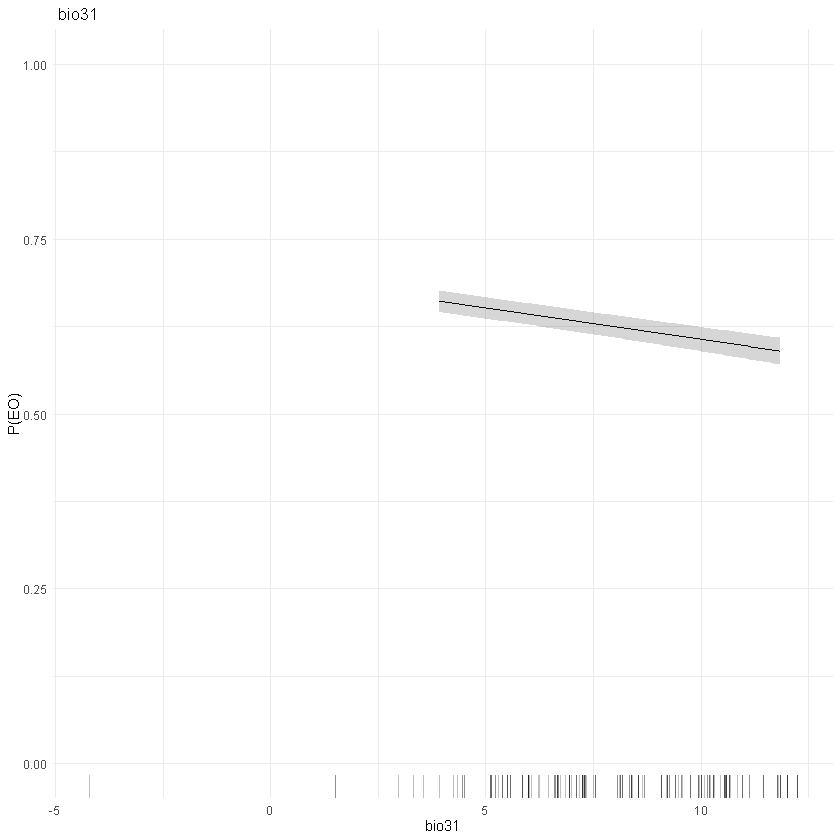

In [26]:
p_forest <- make_partial_plot("bio31", scale = "prob", base_size = 8)
p_forest

In [29]:
summary(gam_fit)$p.table

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),6.822462e+00,1.604530e+00,4.2519989,2.118709e-05
forest,-1.901443e-02,2.024100e-04,-93.9401715,0.000000e+00
elev,-2.699361e-03,2.906949e-05,-92.8589017,0.000000e+00
ph,-1.476119e-02,3.937432e-03,-3.7489399,1.775836e-04
clay,-1.769153e-04,1.080620e-04,-1.6371648,1.015960e-01
sand,1.091098e-03,1.459942e-04,7.4735717,7.804687e-14
bio1,-1.415151e+00,9.275978e-02,-15.2560882,1.499738e-52
bio2,-1.574120e-01,1.245768e-01,-1.2635742,2.063829e-01
bio3,-1.722659e-01,7.087775e-02,-2.4304656,1.507944e-02
bio8,4.246226e-02,3.718500e-03,11.4191900,3.353449e-30


In [30]:
summary(gam_fit)$s.table

,edf,Ref.df,Chi.sq,p-value
"s(longitude,latitude)",98.65471,98.98408,53521.42,0


In [31]:
df$pred_class <- ifelse(df$predicted_prob >= 0.5, "EO", "ES")

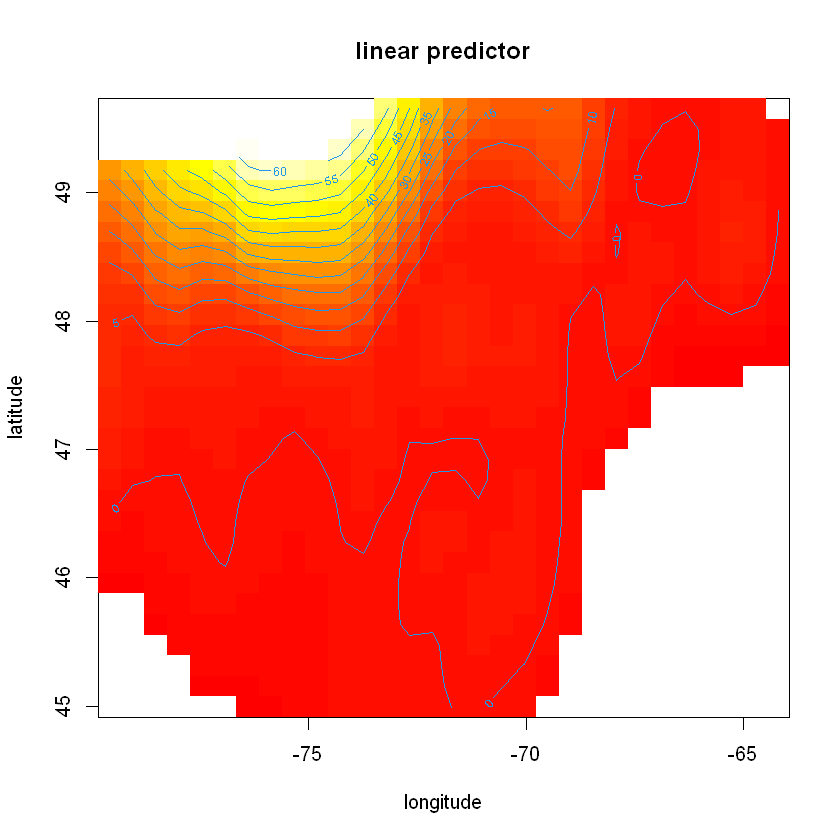

In [33]:
vis.gam(gam_fit, view=c("longitude","latitude"), plot.type="contour", too.far=0.1)


In [87]:
lon_seq <- seq(
  quantile(df$longitude, 0.01, na.rm = TRUE),
  quantile(df$longitude, 0.99, na.rm = TRUE),
  length.out = 200
)

lat_seq <- seq(
  quantile(df$latitude, 0.01, na.rm = TRUE),
  quantile(df$latitude, 0.99, na.rm = TRUE),
  length.out = 200
)

grid <- expand.grid(
  longitude = lon_seq,
  latitude  = lat_seq
)

# 2) Fill all other covariates with typical values (medians)
base_vals <- df %>%
  summarise(
    forest = median(forest, na.rm = TRUE),
    elev   = median(elev,   na.rm = TRUE),
    ph     = median(ph,     na.rm = TRUE),
    clay   = median(clay,   na.rm = TRUE),
    sand   = median(sand,   na.rm = TRUE),
    bio1   = median(bio1,   na.rm = TRUE),
    bio2   = median(bio2,   na.rm = TRUE),
    bio3   = median(bio3,   na.rm = TRUE),
    bio8   = median(bio8,   na.rm = TRUE),
    bio9   = median(bio9,   na.rm = TRUE),
    bio10  = median(bio10,  na.rm = TRUE),
    bio11  = median(bio11,  na.rm = TRUE),
    bio12  = median(bio12,  na.rm = TRUE),
    bio14  = median(bio14,  na.rm = TRUE),
    bio15  = median(bio15,  na.rm = TRUE),
    bio18  = median(bio18,  na.rm = TRUE),
    bio20  = median(bio20,  na.rm = TRUE),
    bio23  = median(bio23,  na.rm = TRUE),
    bio24  = median(bio24,  na.rm = TRUE),
    bio27  = median(bio27,  na.rm = TRUE),
    bio30  = median(bio30,  na.rm = TRUE),
    bio31  = median(bio31,  na.rm = TRUE),
    bio34  = median(bio34,  na.rm = TRUE)
  )

# replicate medians for all grid cells
for (v in names(base_vals)) {
  grid[[v]] <- base_vals[[v]][1]
}

In [88]:
terms_mat <- predict(
  gam_fit,
  newdata = grid,
  type = "terms",
  se.fit = FALSE
)

# Extract the spatial term (column name may look like this)
sp_name <- grep("^s\\(longitude,latitude\\)", colnames(terms_mat), value = TRUE)
grid$spatial_effect <- terms_mat[, sp_name]

# Optionally, centre it so zero is meaningful midpoint
grid$spatial_effect <- grid$spatial_effect - mean(grid$spatial_effect, na.rm = TRUE)

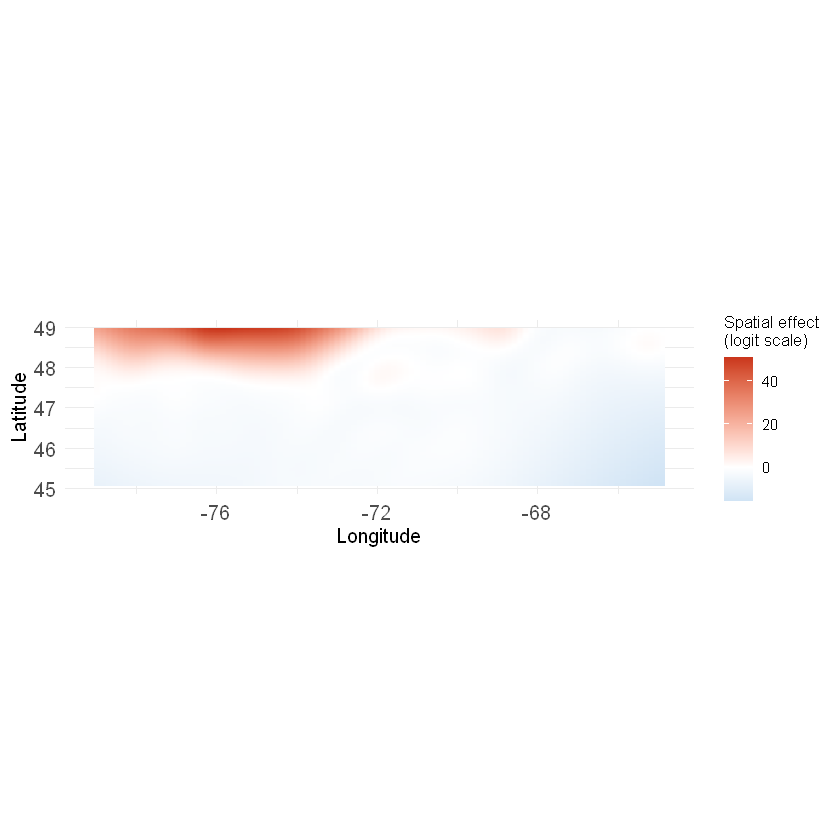

In [90]:
p_spatial <- ggplot(grid, aes(x = longitude, y = latitude, fill = spatial_effect)) +
  geom_raster(interpolate = TRUE) +
  scale_fill_gradient2(
    low  = "#51a7dc",   # ES side
    mid  = "white",
    high = "#ca361c",   # EO side
    midpoint = 0,
    name = "Spatial effect\n(logit scale)"
  ) +
  coord_fixed() +
  labs(
    x = "Longitude",
    y = "Latitude",
    title = ""
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12),
    axis.text.x  = element_text(size = 12),
    axis.text.y  = element_text(size = 12),
    plot.title   = element_text(size = 10, face = "bold"),
    legend.title = element_text(size = 10),
    legend.text  = element_text(size = 9)
  )

p_spatial

In [91]:
ggsave(
  "spatial_smooth_EO_ES.png",
  plot   = p_spatial,
  width  = 4,
  height = 4,
  units  = "cm",
  dpi    = 300
)

In [34]:
#grid$spatial_effect <- predict(gam_fit, grid, type="terms")[,"s(longitude,latitude)"]


In [62]:
centros <- read.csv("data/Centroids.csv")
head(centros)

,cluster_k,longitude,latitude
,<int>,<dbl>,<dbl>
1,0,-70.91104,46.23255
2,1,-73.46555,47.25809
3,2,-66.51589,48.27555
4,3,-73.08631,46.35138


In [63]:
vars_top5 <- c("forest", "elev", "bio31", "bio24", "bio15")

In [64]:
base_medians <- df %>%
  summarise(
    forest = median(forest, na.rm = TRUE),
    elev   = median(elev,   na.rm = TRUE),
    ph     = median(ph,     na.rm = TRUE),
    clay   = median(clay,   na.rm = TRUE),
    sand   = median(sand,   na.rm = TRUE),
    bio1   = median(bio1,   na.rm = TRUE),
    bio2   = median(bio2,   na.rm = TRUE),
    bio3   = median(bio3,   na.rm = TRUE),
    bio8   = median(bio8,   na.rm = TRUE),
    bio9   = median(bio9,   na.rm = TRUE),
    bio10  = median(bio10,  na.rm = TRUE),
    bio11  = median(bio11,  na.rm = TRUE),
    bio12  = median(bio12,  na.rm = TRUE),
    bio14  = median(bio14,  na.rm = TRUE),
    bio15  = median(bio15,  na.rm = TRUE),
    bio18  = median(bio18,  na.rm = TRUE),
    bio20  = median(bio20,  na.rm = TRUE),
    bio23  = median(bio23,  na.rm = TRUE),
    bio24  = median(bio24,  na.rm = TRUE),
    bio27  = median(bio27,  na.rm = TRUE),
    bio30  = median(bio30,  na.rm = TRUE),
    bio31  = median(bio31,  na.rm = TRUE),
    bio34  = median(bio34,  na.rm = TRUE),
    longitude = median(longitude, na.rm = TRUE),
    latitude  = median(latitude,  na.rm = TRUE)
  )


In [80]:
make_partial_at_centroid <- function(var_name,
                                     lon,
                                     lat,
                                     label = NULL,
                                     scale = c("prob", "logit"),
                                     base_size = 12,
                                     n_points = 100,
                                     n_points_rug = 200,
                                     n_breaks_x = 6,
                                     n_breaks_y = 6) {

  scale <- match.arg(scale)

  # Sequence for x
  x_seq <- seq(
    quantile(df[[var_name]], 0.05, na.rm = TRUE),
    quantile(df[[var_name]], 0.95, na.rm = TRUE),
    length.out = n_points
  )

  # Baseline medians
  base_vals <- base_medians
  base_vals$longitude <- lon
  base_vals$latitude  <- lat

  newdat <- base_vals[rep(1, n_points), ]
  newdat[[var_name]] <- x_seq

  # GAM prediction
  pr <- predict(gam_fit, newdata = newdat, type = "link", se.fit = TRUE)
  eta <- pr$fit
  se_eta <- pr$se.fit

  if (scale == "prob") {
    y     <- plogis(eta)
    lower <- plogis(eta - 2 * se_eta)
    upper <- plogis(eta + 2 * se_eta)
    y_lab <- "P(EO)"
    y_limits <- c(0, 1)
  } else {
    y     <- eta
    lower <- eta - 2 * se_eta
    upper <- eta + 2 * se_eta
    y_lab <- "logit(P(EO))"
    y_limits <- NA
  }

  newdat$y <- y
  newdat$ymin <- lower
  newdat$ymax <- upper

  # Data for rug
  df_clean <- df %>% dplyr::filter(!is.na(.data[[var_name]]))
  rug_n <- min(n_points_rug, nrow(df_clean))
  df_rug <- df_clean %>% dplyr::slice_sample(n = rug_n)

  # Ticks compact
  x_breaks <- pretty(range(x_seq), n = n_breaks_x)
  y_breaks <- if (!any(is.na(y_limits))) {
    pretty(y_limits, n = n_breaks_y)
  } else {
    pretty(range(newdat$y), n = n_breaks_y)
  }

  # Title only cluster
  title_txt <- paste0("Cluster ", label)

  ggplot(newdat, aes(x = x_seq, y = y)) +
    geom_line() +
    geom_ribbon(aes(ymin = ymin, ymax = ymax), alpha = 0.2) +
    geom_rug(
      data = df_rug,
      aes(x = .data[[var_name]]),
      inherit.aes = FALSE,
      sides = "b",
      alpha = 0.25
    ) +
    scale_x_continuous(breaks = x_breaks) +
    scale_y_continuous(breaks = y_breaks,
                       limits = if (!any(is.na(y_limits))) y_limits else NULL) +
    labs(x = var_name, y = y_lab, title = title_txt) +
    theme_minimal(base_size = base_size) +
    theme(
      plot.title   = element_text(size = 7, face = "bold"),
      axis.text.x  = element_text(size = 9),
      axis.text.y  = element_text(size = 9),
      axis.title.x = element_text(size = 12),
      axis.title.y = element_text(size = 12)
    )
}



In [86]:
dir.create("plots_centroids", showWarnings = FALSE)

for (i in 1:nrow(centros)) {
  lon_i <- centros$longitude[i]
  lat_i <- centros$latitude[i]
  lab_i <- if ("cluster_k" %in% names(centros)) centros$cluster_k[i] else i - 1

  for (v in vars_top5) {
    p <- make_partial_at_centroid(
      var_name = v,
      lon      = lon_i,
      lat      = lat_i,
      label    = lab_i,
      scale    = "prob",
      base_size = 12
    )

    ggsave(
      filename = sprintf("plots_centroids/centroid_%s_%s.png", lab_i, v),
      plot     = p,
      width    = 8,
      height   = 4,
      units    = "cm",
      dpi      = 300
    )
  }
}


In [82]:
# build newdata with medians for everything, but lon/lat = centroid
new_centroid_data <- do.call(rbind, lapply(1:nrow(centros), function(i) {
  out <- base_medians
  out$longitude <- centros$longitude[i]
  out$latitude  <- centros$latitude[i]
  if ("cluster_k" %in% names(centros)) out$cluster_k <- centros$cluster_k[i]
  out
}))

new_centroid_data$pred_prob <- predict(gam_fit, newdata = new_centroid_data, type = "response")
new_centroid_data

forest,elev,ph,clay,sand,bio1,bio2,bio3,bio8,bio9,⋯,bio23,bio24,bio27,bio30,bio31,bio34,longitude,latitude,cluster_k,pred_prob
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
100,324,4.6167,16,65,2.888086,11.24351,24.75931,8.32504,-2.266831,⋯,81.18204,617.75,33.60291,-2.733226,8.11378,755.944,-70.91104,46.23255,0,0.6355301
100,324,4.6167,16,65,2.888086,11.24351,24.75931,8.32504,-2.266831,⋯,81.18204,617.75,33.60291,-2.733226,8.11378,755.944,-73.46555,47.25809,1,0.8925371
100,324,4.6167,16,65,2.888086,11.24351,24.75931,8.32504,-2.266831,⋯,81.18204,617.75,33.60291,-2.733226,8.11378,755.944,-66.51589,48.27555,2,0.4741491
100,324,4.6167,16,65,2.888086,11.24351,24.75931,8.32504,-2.266831,⋯,81.18204,617.75,33.60291,-2.733226,8.11378,755.944,-73.08631,46.35138,3,0.4020481


In [68]:
base_medians <- df %>%
  summarise(
    forest = median(forest, na.rm = TRUE),
    elev   = median(elev,   na.rm = TRUE),
    ph     = median(ph,     na.rm = TRUE),
    clay   = median(clay,   na.rm = TRUE),
    sand   = median(sand,   na.rm = TRUE),
    bio1   = median(bio1,   na.rm = TRUE),
    bio2   = median(bio2,   na.rm = TRUE),
    bio3   = median(bio3,   na.rm = TRUE),
    bio8   = median(bio8,   na.rm = TRUE),
    bio9   = median(bio9,   na.rm = TRUE),
    bio10  = median(bio10,  na.rm = TRUE),
    bio11  = median(bio11,  na.rm = TRUE),
    bio12  = median(bio12,  na.rm = TRUE),
    bio14  = median(bio14,  na.rm = TRUE),
    bio15  = median(bio15,  na.rm = TRUE),
    bio18  = median(bio18,  na.rm = TRUE),
    bio20  = median(bio20,  na.rm = TRUE),
    bio23  = median(bio23,  na.rm = TRUE),
    bio24  = median(bio24,  na.rm = TRUE),
    bio27  = median(bio27,  na.rm = TRUE),
    bio30  = median(bio30,  na.rm = TRUE),
    bio31  = median(bio31,  na.rm = TRUE),
    bio34  = median(bio34,  na.rm = TRUE),
    longitude = median(longitude, na.rm = TRUE),
    latitude  = median(latitude,  na.rm = TRUE)
  )

In [69]:

# Repetimos la fila de medianas tantas veces como centroides
new_centroid_data <- base_medians[rep(1, nrow(centros)), ]

# Sustituimos lon/lat por los centroides
new_centroid_data$longitude <- centros$longitude
new_centroid_data$latitude  <- centros$latitude

# Si quieres arrastrar el ID de cluster:
if ("cluster_k" %in% names(centros)) {
  new_centroid_data$cluster_k <- centros$cluster_k
} else {
  new_centroid_data$cluster_k <- seq_len(nrow(centros)) - 1
}

In [70]:
# Predicción en escala lineal (logit), con error estándar
pr <- predict(gam_fit,
              newdata = new_centroid_data,
              type = "link",
              se.fit = TRUE)

new_centroid_data$eta       <- pr$fit     # predicción en logit
new_centroid_data$se_eta    <- pr$se.fit  # error estándar en logit

# Probabilidad P(EO) = plogis(eta)
new_centroid_data$prob_EO   <- plogis(new_centroid_data$eta)

# Delta method para SE en probabilidad:
# var(p) ≈ (p * (1-p))^2 * var(eta)  =>  se_p ≈ se_eta * p * (1-p)
new_centroid_data$se_prob   <- new_centroid_data$se_eta *
                               new_centroid_data$prob_EO *
                               (1 - new_centroid_data$prob_EO)

# Intervalo de confianza 95% en probabilidad (transformando el CI en logit)
new_centroid_data$prob_low  <- plogis(new_centroid_data$eta - 1.96 * new_centroid_data$se_eta)
new_centroid_data$prob_high <- plogis(new_centroid_data$eta + 1.96 * new_centroid_data$se_eta)

# Resultado final
new_centroid_data_out <- new_centroid_data %>%
  select(cluster_k, longitude, latitude,
         prob_EO, se_prob, prob_low, prob_high, eta, se_eta)

new_centroid_data_out

,cluster_k,longitude,latitude,prob_EO,se_prob,prob_low,prob_high,eta,se_eta
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,-70.91104,46.23255,0.6355301,0.009974073,0.6157666,0.6548469,0.5560157,0.04306008
1.1,1,-73.46555,47.25809,0.8925371,0.004148160,0.8841321,0.9004011,2.1169223,0.04324846
1.2,2,-66.51589,48.27555,0.4741491,0.013811630,0.4471805,0.5012694,-0.1034960,0.05539459
1.3,3,-73.08631,46.35138,0.4020481,0.007663625,0.3871236,0.4171564,-0.3969385,0.03187792


dve

In [71]:
partial_stats_at_centroid <- function(var_name,
                                      lon,
                                      lat,
                                      scale = c("prob", "logit"),
                                      n_points = 100) {

  scale <- match.arg(scale)

  # 1. Secuencia de la variable
  x_seq <- seq(
    quantile(df[[var_name]], 0.05, na.rm = TRUE),
    quantile(df[[var_name]], 0.95, na.rm = TRUE),
    length.out = n_points
  )

  # 2. Valores típicos para el resto (baseline)
  base_vals <- base_medians

  # 3. Override del centroide
  base_vals$longitude <- lon
  base_vals$latitude  <- lat

  # 4. Expandir newdata
  newdat <- base_vals[rep(1, n_points), ]
  newdat[[var_name]] <- x_seq

  # 5. Predecir en escala lineal
  pr <- predict(gam_fit, newdata = newdat, type = "link", se.fit = TRUE)

  eta <- pr$fit
  se_eta <- pr$se.fit

  if (scale == "prob") {
    p <- plogis(eta)
    lower <- plogis(eta - 1.96 * se_eta)
    upper <- plogis(eta + 1.96 * se_eta)
  } else {
    p <- eta
    lower <- eta - 1.96 * se_eta
    upper <- eta + 1.96 * se_eta
  }

  # Estadísticas resumidas para la variable
  tibble(
    variable = var_name,
    centroid_lon = lon,
    centroid_lat = lat,
    mean_pred = mean(p),
    sd_pred   = sd(p),
    se_pred   = sd(p) / sqrt(n_points),
    ci_low    = mean(p) - 1.96 * sd(p)/sqrt(n_points),
    ci_high   = mean(p) + 1.96 * sd(p)/sqrt(n_points)
  )
}

In [72]:


results <- list()

for (i in 1:nrow(centros)) {
  lon_i <- centros$longitude[i]
  lat_i <- centros$latitude[i]
  cluster_i <- if ("cluster_k" %in% names(centros)) centros$cluster_k[i] else i-1

  for (v in vars_top5) {
    res <- partial_stats_at_centroid(
      var_name = v,
      lon = lon_i,
      lat = lat_i,
      scale = "prob"
    )
    res$cluster_k <- cluster_i
    results[[length(results) + 1]] <- res
  }
}

centroid_gam_summary <- bind_rows(results)
centroid_gam_summary


variable,centroid_lon,centroid_lat,mean_pred,sd_pred,se_pred,ci_low,ci_high,cluster_k
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
forest,-70.91104,46.23255,0.6737985,0.022013297,0.0022013297,0.6694839,0.6781131,0
elev,-70.91104,46.23255,0.6493495,0.075676412,0.0075676412,0.6345170,0.6641821,0
bio31,-70.91104,46.23255,0.6373037,0.020589760,0.0020589760,0.6332681,0.6413393,0
bio24,-70.91104,46.23255,0.6575705,0.113339697,0.0113339697,0.6353559,0.6797851,0
bio15,-70.91104,46.23255,0.6278087,0.032469396,0.0032469396,0.6214447,0.6341727,0
forest,-73.46555,47.25809,0.9075430,0.008406079,0.0008406079,0.9058954,0.9091906,1
elev,-73.46555,47.25809,0.8956287,0.031161455,0.0031161455,0.8895211,0.9017364,1
bio31,-73.46555,47.25809,0.8930781,0.008507668,0.0008507668,0.8914106,0.8947456,1
bio24,-73.46555,47.25809,0.8957273,0.047340380,0.0047340380,0.8864486,0.9050060,1


In [73]:
centroid_gam_summary <- centroid_gam_summary %>%
  mutate(
    mean_ES  = 1 - mean_pred,
    sd_ES    = sd_pred,         # identical
    se_ES    = se_pred,         # identical
    ci_low_ES  = 1 - ci_high,   # reversed
    ci_high_ES = 1 - ci_low
  )

In [74]:
centroid_gam_summary

variable,centroid_lon,centroid_lat,mean_pred,sd_pred,se_pred,ci_low,ci_high,cluster_k,mean_ES,sd_ES,se_ES,ci_low_ES,ci_high_ES
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
forest,-70.91104,46.23255,0.6737985,0.022013297,0.0022013297,0.6694839,0.6781131,0,0.32620154,0.022013297,0.0022013297,0.32188693,0.33051614
elev,-70.91104,46.23255,0.6493495,0.075676412,0.0075676412,0.6345170,0.6641821,0,0.35065046,0.075676412,0.0075676412,0.33581788,0.36548303
bio31,-70.91104,46.23255,0.6373037,0.020589760,0.0020589760,0.6332681,0.6413393,0,0.36269628,0.020589760,0.0020589760,0.35866069,0.36673187
bio24,-70.91104,46.23255,0.6575705,0.113339697,0.0113339697,0.6353559,0.6797851,0,0.34242953,0.113339697,0.0113339697,0.32021495,0.36464411
bio15,-70.91104,46.23255,0.6278087,0.032469396,0.0032469396,0.6214447,0.6341727,0,0.37219130,0.032469396,0.0032469396,0.36582730,0.37855531
forest,-73.46555,47.25809,0.9075430,0.008406079,0.0008406079,0.9058954,0.9091906,1,0.09245704,0.008406079,0.0008406079,0.09080945,0.09410463
elev,-73.46555,47.25809,0.8956287,0.031161455,0.0031161455,0.8895211,0.9017364,1,0.10437126,0.031161455,0.0031161455,0.09826362,0.11047891
bio31,-73.46555,47.25809,0.8930781,0.008507668,0.0008507668,0.8914106,0.8947456,1,0.10692194,0.008507668,0.0008507668,0.10525444,0.10858945
bio24,-73.46555,47.25809,0.8957273,0.047340380,0.0047340380,0.8864486,0.9050060,1,0.10427270,0.047340380,0.0047340380,0.09499398,0.11355141
